In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy import optimize
import statsmodels as sm
from scipy.optimize import curve_fit
import statsmodels.stats.multicomp as mc

In [2]:
df = pd.read_csv('oil.csv')

In [3]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ReportDate', 'API_WELLNO', 'FileNo',
       'Company', 'WellName', 'Quarter', 'Section', 'Township', 'Range',
       'County', 'FieldName', 'Pool', 'Oil', 'Wtr', 'Days', 'Runs', 'Gas',
       'GasSold', 'Flared', 'Lat', 'Long', 'Online_Date', 'Days_Online'],
      dtype='object')

In [4]:
df.datetime(['ReportDate'])

AttributeError: 'DataFrame' object has no attribute 'datetime'

In [5]:
df['ReportDate'] = pd.to_datetime(df['ReportDate'])

In [6]:
df['Online_Date'] = pd.to_datetime(df['Online_Date'])

In [7]:
df.rename(columns={'Oil': 'Oil Prod'}, inplace=True)
df.rename(columns={'Wtr': 'Water Prod'}, inplace=True)
df.rename(columns={'Days': 'Days Prod'}, inplace=True)
df.rename(columns={'API_WELLNO': 'API'}, inplace=True)

In [8]:
df.head(5)

,Unnamed: 0.1,Unnamed: 0,ReportDate,API,FileNo,Company,WellName,Quarter,Section,Township,...,Water Prod,Days Prod,Runs,Gas,GasSold,Flared,Lat,Long,Online_Date,Days_Online
0,14709,51,2016-01-01,3.306101e+13,17795.0,"EOG RESOURCES, INC.",ROSS 3-04H,LOT3,4.0,156.0,...,572.0,13.0,625.0,644.0,524.0,0.0,48.371760,-102.520252,2016-01-01,0
1,14859,201,2016-01-01,3.306101e+13,16893.0,STATOIL OIL & GAS LP,BAKKE 23 1-H,NWNW,23.0,155.0,...,227.0,3.0,0.0,4.0,4.0,0.0,48.239382,-102.481139,2016-01-01,0
2,14876,218,2016-01-01,3.306101e+13,19058.0,STATOIL OIL & GAS LP,BURES 20-29 #1TFH,NWNE,20.0,155.0,...,4638.0,27.0,3731.0,2823.0,2540.0,283.0,48.239688,-102.665406,2016-01-01,0
3,14941,283,2016-01-01,3.306102e+13,22461.0,STATOIL OIL & GAS LP,LIFFRIG 29-20 #4H,SWSW,29.0,156.0,...,4704.0,13.0,4777.0,7554.0,7121.0,433.0,48.299268,-102.671472,2016-01-01,0
4,14947,289,2016-01-01,3.306102e+13,22007.0,STATOIL OIL & GAS LP,PANZER 22-23 #1-H,SWSW,22.0,155.0,...,2.0,1.0,386.0,6.0,6.0,0.0,48.228895,-102.502487,2016-01-01,0


In [9]:
df['API'] = df['API'].astype(str).str.replace('.0', '', regex=False)

In [10]:
# Flag shut-in months (well barely ran that month)
df['ShutIn'] = df['Days Prod'] < 15

# Remove shut-in months for curve fitting
df_active = df[df['ShutIn'] == False].copy()

# Keep only wells with 12 or more active months
months_per_well = df_active.groupby('API')['ReportDate'].count()
wells_12plus    = months_per_well[months_per_well >= 12].index
df_clean        = df_active[df_active['API'].isin(wells_12plus)].copy()

# Sort by well and date
df_clean = df_clean.sort_values(['API', 'ReportDate']).reset_index(drop=True)

# Add MonthIndex — each well's clock starts at 0
df_clean['MonthIndex'] = df_clean.groupby('API').cumcount()

print(f"Wells remaining: {df_clean['API'].nunique()}")
print(f"Rows remaining: {len(df_clean):,}")

Wells remaining: 748
Rows remaining: 22,723


In [11]:
# Define the exponential decline equation 
def exponential_decline(t, q0, D):
    return q0 * np.exp(-D * t)

#  Fit the curve for every well 
results = []

for api, group in df_clean.groupby('API'):
    group = group.sort_values('MonthIndex')
    t     = group['MonthIndex'].values
    q     = group['Oil Prod'].values

    try:
        # curve_fit returns best fit parameters
        popt, pcov = curve_fit(
            exponential_decline,
            t, q,
            p0=[q.max(), 0.05],   # initial guesses: q0=max production, D=5%
            bounds=([0, 0], [np.inf, 1]),
            maxfev=5000
        )
        q0_fit, D_fit = popt

        # R² tells us how well the curve fits (1.0 = perfect)
        q_pred  = exponential_decline(t, *popt)
        ss_res  = np.sum((q - q_pred) ** 2)
        ss_tot  = np.sum((q - np.mean(q)) ** 2)
        r2      = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        results.append({
            'API':       api,
            'WellName':  group['WellName'].iloc[0],
            'FieldName': group['FieldName'].iloc[0],
            'q0':        q0_fit,
            'D':         D_fit,
            'R2':        r2,
            'Months':    len(group)
        })

    except Exception:
        # If curve fitting fails for a well, skip it
        pass

# Convert to dataframe
df_results = pd.DataFrame(results)

print(f"Wells successfully fitted: {len(df_results)}")
print(f"Wells that failed:         {748 - len(df_results)}")
print(f"\nDecline rate (D) summary:")
print(df_results['D'].describe().round(4))
print(f"\nR² summary:")
print(df_results['R2'].describe().round(3))

Wells successfully fitted: 748
Wells that failed:         0

Decline rate (D) summary:
count    748.0000
mean       0.0664
std        0.0675
min        0.0000
25%        0.0233
50%        0.0567
75%        0.0899
max        1.0000
Name: D, dtype: float64

R² summary:
count    748.000
mean       0.555
std        0.305
min       -0.000
25%        0.318
50%        0.659
75%        0.802
max        0.975
Name: R2, dtype: float64


In [12]:
# for the hyperbolic model
good_fit    = (df_results['R2'] >= 0.7).sum()
decent_fit  = ((df_results['R2'] >= 0.5) & (df_results['R2'] < 0.7)).sum()
poor_fit    = (df_results['R2'] < 0.5).sum()

print(f"Good fit  (R² ≥ 0.7): {good_fit} wells  ({good_fit/748*100:.1f}%)")
print(f"Decent fit (R² 0.5–0.7): {decent_fit} wells ({decent_fit/748*100:.1f}%)")
print(f"Poor fit  (R² < 0.5):  {poor_fit} wells  ({poor_fit/748*100:.1f}%)")

Good fit  (R² ≥ 0.7): 338 wells  (45.2%)
Decent fit (R² 0.5–0.7): 144 wells (19.3%)
Poor fit  (R² < 0.5):  266 wells  (35.6%)


In [13]:
#  Define hyperbolic decline equation 
def hyperbolic_decline(t, q0, D, b):
    return q0 / (1 + b * D * t) ** (1 / b)

# Fit hyperbolic curve for every well 
hyp_results = []

for api, group in df_clean.groupby('API'):
    group = group.sort_values('MonthIndex')
    t     = group['MonthIndex'].values
    q     = group['Oil Prod'].values

    try:
        popt, pcov = curve_fit(
            hyperbolic_decline,
            t, q,
            p0=[q.max(), 0.05, 0.5],        # initial guesses: q0, D, b=0.5
            bounds=([0, 0, 0.01], [np.inf, 1, 0.99]),
            maxfev=10000
        )
        q0_fit, D_fit, b_fit = popt

        # R² for hyperbolic
        q_pred = hyperbolic_decline(t, *popt)
        ss_res = np.sum((q - q_pred) ** 2)
        ss_tot = np.sum((q - np.mean(q)) ** 2)
        r2     = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        hyp_results.append({
            'API':       api,
            'WellName':  group['WellName'].iloc[0],
            'FieldName': group['FieldName'].iloc[0],
            'q0_hyp':    q0_fit,
            'D_hyp':     D_fit,
            'b':         b_fit,
            'R2_hyp':    r2,
            'Months':    len(group)
        })

    except Exception:
        pass

df_hyp = pd.DataFrame(hyp_results)

print(f"Hyperbolic fits completed: {len(df_hyp)}")
print(f"\nHyperbolic R² summary:")
print(df_hyp['R2_hyp'].describe().round(3))

# ── Compare: which model wins per well? ───────────────────────
df_compare = df_results.merge(
    df_hyp[['API','R2_hyp','D_hyp','b','q0_hyp']],
    on='API', how='inner'
)

df_compare['BestModel'] = np.where(
    df_compare['R2_hyp'] > df_compare['R2'],
    'Hyperbolic',
    'Exponential'
)

exp_wins = (df_compare['BestModel'] == 'Exponential').sum()
hyp_wins = (df_compare['BestModel'] == 'Hyperbolic').sum()

print(f"\n--- Best Model Per Well ---")
print(f"Exponential wins: {exp_wins} wells ({exp_wins/len(df_compare)*100:.1f}%)")
print(f"Hyperbolic wins:  {hyp_wins} wells ({hyp_wins/len(df_compare)*100:.1f}%)")

Hyperbolic fits completed: 748

Hyperbolic R² summary:
count    748.000
mean       0.592
std        0.324
min       -0.000
25%        0.340
50%        0.707
75%        0.863
max        0.991
Name: R2_hyp, dtype: float64

--- Best Model Per Well ---
Exponential wins: 257 wells (34.4%)
Hyperbolic wins:  491 wells (65.6%)


In [14]:
#  Build master results table 
# Use best model's D value and R² for each well

df_master = df_compare.copy()

# Best decline rate — use hyperbolic D where it won, exponential D otherwise
df_master['Best_D']  = np.where(
    df_master['BestModel'] == 'Hyperbolic',
    df_master['D_hyp'],
    df_master['D']
)

# Best R²
df_master['Best_R2'] = np.where(
    df_master['BestModel'] == 'Hyperbolic',
    df_master['R2_hyp'],
    df_master['R2']
)

# Best q0 (initial production rate)
df_master['Best_q0'] = np.where(
    df_master['BestModel'] == 'Hyperbolic',
    df_master['q0_hyp'],
    df_master['q0']
)

# Keep b for hyperbolic wells (exponential wells get b=0)
df_master['Best_b'] = df_master['b'].fillna(0)

print("Master results table built")
print(f"Wells: {len(df_master)}")
print(f"\nColumns: {df_master[['API','WellName','FieldName','BestModel','Best_q0','Best_D','Best_b','Best_R2']].columns.tolist()}")
print(f"\nSample rows:")
print(df_master[['WellName','FieldName','BestModel',
                  'Best_D','Best_R2']].head(8).to_string())

Master results table built
Wells: 748

Columns: ['API', 'WellName', 'FieldName', 'BestModel', 'Best_q0', 'Best_D', 'Best_b', 'Best_R2']

Sample rows:
                            WellName      FieldName    BestModel        Best_D       Best_R2
0                       STATE  2-13H          T. R.  Exponential  3.825339e-19  0.000000e+00
1  BIG STICK (MADISON) UNIT     3209      BIG STICK  Exponential  7.032651e-04  2.523838e-04
2                   FEDERAL     2-28       TREE TOP  Exponential  1.932215e-04  1.266771e-04
3          LAUDIE BURIAN     1-23-3C   LITTLE KNIFE  Exponential  9.577102e-03  5.035524e-02
4              ELKHORN FEDERAL     2  ELKHORN RANCH   Hyperbolic  1.581551e-16 -3.219647e-14
5                     SFTU     14-24        FRYBURG  Exponential  2.853957e-03  1.075653e-02
6                  FEDERAL  19-21 HR         MEDORA   Hyperbolic  1.657698e-02  3.595405e-01
7                    ROOSEVELT  22-5      ROOSEVELT   Hyperbolic  2.000173e-02  3.369617e-01


In [15]:
# Remove unreliable fits 

before = len(df_master)

df_master = df_master[
    (df_master['Best_R2']  >  0.1) &   # curve must explain some variance
    (df_master['Best_D']   >  0.001) &  # decline rate must be meaningful
    (df_master['Best_D']   <  0.99)     # exclude wells that hit the upper bound
].copy().reset_index(drop=True)

after = len(df_master)

print(f"Wells before filter: {before}")
print(f"Wells removed:       {before - after}")
print(f"Wells remaining:     {after}")
print(f"\nBest_D summary after cleaning:")
print(df_master['Best_D'].describe().round(4))
print(f"\nBest_R2 summary after cleaning:")
print(df_master['Best_R2'].describe().round(3))
print(f"\nSample rows:")
print(df_master[['WellName','FieldName','BestModel',
                  'Best_D','Best_R2']].head(8).to_string())

Wells before filter: 748
Wells removed:       115
Wells remaining:     633

Best_D summary after cleaning:
count    633.0000
mean       0.1481
std        0.1506
min        0.0055
25%        0.0468
50%        0.0947
75%        0.2039
max        0.9329
Name: Best_D, dtype: float64

Best_R2 summary after cleaning:
count    633.000
mean       0.694
std        0.233
min        0.101
25%        0.552
50%        0.767
75%        0.879
max        0.991
Name: Best_R2, dtype: float64

Sample rows:
                                   WellName      FieldName    BestModel    Best_D   Best_R2
0                         FEDERAL  19-21 HR         MEDORA   Hyperbolic  0.016577  0.359541
1                           ROOSEVELT  22-5      ROOSEVELT   Hyperbolic  0.020002  0.336962
2                  MARY SAMSONITE  3-16-21H  ST. DEMETRIUS   Hyperbolic  0.068683  0.753357
3  NEWBURG-SPEARFISH-CHARLES UNIT     R-712        NEWBURG   Hyperbolic  0.072387  0.796541
4  NEWBURG-SPEARFISH-CHARLES UNIT     I-719    

In [16]:
# Hypothesis Testing 

# Calculate field level mean and std of decline rates
field_stats = (df_master
               .groupby('FieldName')['Best_D']
               .agg(['mean', 'std', 'count'])
               .rename(columns={'mean':'Field_Mean_D',
                                 'std': 'Field_Std_D',
                                 'count':'Field_Well_Count'})
               .reset_index())

# Only test fields with 3+ wells (need enough wells for meaningful stats)
field_stats = field_stats[field_stats['Field_Well_Count'] >= 3]

# Merge field stats back onto master table
df_master = df_master.merge(field_stats, on='FieldName', how='inner')

print(f"Wells in fields with 3+ members: {len(df_master)}")
print(f"Fields being tested: {df_master['FieldName'].nunique()}")

# Calculate Z-score for every well
df_master['Z_Score'] = (
    (df_master['Best_D'] - df_master['Field_Mean_D']) /
     df_master['Field_Std_D']
)

# Calculate two-tailed p-value from Z-score
df_master['P_Value'] = 2 * (1 - stats.norm.cdf(abs(df_master['Z_Score'])))

# Flag wells with statistically significant decline
df_master['Significant'] = df_master['P_Value'] < 0.05

# Summary
sig_wells   = df_master['Significant'].sum()
total_wells = len(df_master)

print(f"\n--- Hypothesis Test Results ---")
print(f"Total wells tested:              {total_wells}")
print(f"Significantly declining wells:   {sig_wells} ({sig_wells/total_wells*100:.1f}%)")
print(f"Normal decline wells:            {total_wells - sig_wells} ({(total_wells-sig_wells)/total_wells*100:.1f}%)")

print(f"\nTop 10 fastest significantly declining wells:")
top_declining = (df_master[df_master['Significant']]
                 .sort_values('Best_D', ascending=False)
                 [['WellName','FieldName','Best_D','Z_Score','P_Value','Best_R2']]
                 .head(10))
print(top_declining.to_string())

Wells in fields with 3+ members: 532
Fields being tested: 59

--- Hypothesis Test Results ---
Total wells tested:              532
Significantly declining wells:   26 (4.9%)
Normal decline wells:            506 (95.1%)

Top 10 fastest significantly declining wells:
                              WellName         FieldName    Best_D   Z_Score   P_Value   Best_R2
209                 AMUNDSON  44-22NWH         SIVERSTON  0.932945  3.714748  0.000203  0.790981
61            SNOWY  147-94-13A-24H TF  MCGREGORY BUTTES  0.873219  2.980302  0.002880  0.924781
456  CA-RUSSELL SMITH-  155-96-2425H-4              CAPA  0.833944  1.987127  0.046908  0.980666
179       AN-EVENSON-  152-95-0310H-14          ANTELOPE  0.827646  2.608300  0.009099  0.967402
258      HA-GRIMESTAD-  152-95-3031H-6           HAWKEYE  0.773866  1.981947  0.047485  0.958432
359    EN-CVANCARA-  LE-155-93-1522H-1             ALGER  0.752693  3.181734  0.001464  0.874948
158              LARSEN  152-96-9-3HLW          WESTBER

In [17]:
# Production Forecasting 

economic_threshold = 300  # barrels/month
forecast_months    = 6

forecast_results = []

for _, well in df_master.iterrows():

    # Get this well's last known production
    well_history = df_clean[df_clean['API'] == well['API']].sort_values('MonthIndex')
    
    if len(well_history) == 0:
        continue

    last_prod      = well_history['Oil Prod'].iloc[-1]
    last_month_idx = well_history['MonthIndex'].iloc[-1]

    # Project 6 months forward
    future_months = np.arange(1, forecast_months + 1)
    
    if well['BestModel'] == 'Exponential':
        forecast = well['Best_q0'] * np.exp(-well['Best_D'] * 
                   (last_month_idx + future_months))
    else:
        forecast = (well['Best_q0'] / 
                   (1 + well['Best_b'] * well['Best_D'] * 
                   (last_month_idx + future_months)) ** 
                   (1 / well['Best_b']))

    # Check if any forecast month drops below threshold
    crosses_threshold = any(forecast < economic_threshold)
    
    # Find which month it crosses (if it does)
    months_until_threshold = None
    for i, val in enumerate(forecast):
        if val < economic_threshold:
            months_until_threshold = i + 1
            break

    forecast_results.append({
        'API':                    well['API'],
        'WellName':               well['WellName'],
        'FieldName':              well['FieldName'],
        'BestModel':              well['BestModel'],
        'Best_D':                 well['Best_D'],
        'Last_Production':        last_prod,
        'Significant':            well['Significant'],
        'Forecast_M1':            round(forecast[0], 1),
        'Forecast_M2':            round(forecast[1], 1),
        'Forecast_M3':            round(forecast[2], 1),
        'Forecast_M4':            round(forecast[3], 1),
        'Forecast_M5':            round(forecast[4], 1),
        'Forecast_M6':            round(forecast[5], 1),
        'Crosses_Threshold':      crosses_threshold,
        'Months_Until_Threshold': months_until_threshold
    })

df_forecast = pd.DataFrame(forecast_results)

# Summary
at_risk = df_forecast['Crosses_Threshold'].sum()
critical = df_forecast[
    df_forecast['Months_Until_Threshold'] <= 3
]['Months_Until_Threshold'].count()

print(f"--- 6-Month Production Forecast ---")
print(f"Total wells forecasted:               {len(df_forecast)}")
print(f"Wells crossing threshold in 6 months: {at_risk} ({at_risk/len(df_forecast)*100:.1f}%)")
print(f"Critical — cross within 3 months:     {critical}")

print(f"\nTop 10 most at-risk wells:")
at_risk_wells = (df_forecast[df_forecast['Crosses_Threshold']]
                 .sort_values('Months_Until_Threshold')
                 [['WellName','FieldName','Last_Production',
                   'Best_D','Forecast_M3','Forecast_M6',
                   'Months_Until_Threshold']]
                 .head(10))
print(at_risk_wells.to_string())

--- 6-Month Production Forecast ---
Total wells forecasted:               532
Wells crossing threshold in 6 months: 49 (9.2%)
Critical — cross within 3 months:     40

Top 10 most at-risk wells:
                                     WellName FieldName  Last_Production    Best_D  Forecast_M3  Forecast_M6  Months_Until_Threshold
0    NEWBURG-SPEARFISH-CHARLES UNIT     R-712   NEWBURG             65.0  0.072387         36.7         34.0                     1.0
180              AN-EVENSON-  152-95-0310H-13  ANTELOPE            721.0  0.277797        189.2        147.1                     1.0
201               ANDERSMADSON  5201 43-24 9B      CAMP           1943.0  0.177816         35.8         21.0                     1.0
204               ANDERSMADSON  5201 42-24 4T      CAMP            430.0  0.138656        107.4         70.9                     1.0
265                           ERNIE  3-2-11BH     GRAIL            561.0  0.134955        141.1         94.1                     1.0
267    

In [18]:
# Confidence Intervals 

confidence    = 0.90   # 90% confidence interval
forecast_qtr  = 3      # next quarter = 3 months ahead
economic_threshold = 300

ci_results = []

for _, well in df_master.iterrows():

    # Get well history
    well_history = (df_clean[df_clean['API'] == well['API']]
                    .sort_values('MonthIndex'))

    if len(well_history) < 5:
        continue

    t = well_history['MonthIndex'].values
    q = well_history['Oil Prod'].values
    last_t = t[-1]
    forecast_t = last_t + forecast_qtr

    try:
        if well['BestModel'] == 'Exponential':

            popt, pcov = curve_fit(
                exponential_decline, t, q,
                p0=[q.max(), 0.05],
                bounds=([0, 0], [np.inf, 1]),
                maxfev=5000
            )
            # Point forecast
            point_forecast = exponential_decline(forecast_t, *popt)

            # Standard error from covariance matrix
            # Propagate uncertainty through the equation
            perr        = np.sqrt(np.diag(pcov))
            q0_err      = perr[0]
            D_err       = perr[1]
            q0_fit, D_fit = popt

            # Partial derivatives for error propagation
            dq_dq0 = np.exp(-D_fit * forecast_t)
            dq_dD  = -forecast_t * q0_fit * np.exp(-D_fit * forecast_t)
            se     = np.sqrt((dq_dq0 * q0_err)**2 + (dq_dD * D_err)**2)

        else:
            popt, pcov = curve_fit(
                hyperbolic_decline, t, q,
                p0=[q.max(), 0.05, 0.5],
                bounds=([0, 0, 0.01], [np.inf, 1, 0.99]),
                maxfev=10000
            )
            point_forecast = hyperbolic_decline(forecast_t, *popt)

            perr            = np.sqrt(np.diag(pcov))
            q0_err, D_err, b_err = perr
            q0_fit, D_fit, b_fit = popt

            # Partial derivatives for hyperbolic
            base   = 1 + b_fit * D_fit * forecast_t
            dq_dq0 = base ** (-1 / b_fit)
            dq_dD  = (-forecast_t * q0_fit * base ** (-1/b_fit - 1))
            dq_db  = (q0_fit * base**(-1/b_fit) *
                     (np.log(base) / b_fit**2 -
                      D_fit * forecast_t / (b_fit * base)))
            se     = np.sqrt((dq_dq0*q0_err)**2 +
                             (dq_dD*D_err)**2 +
                             (dq_db*b_err)**2)

        # Degrees of freedom
        n_params = 2 if well['BestModel'] == 'Exponential' else 3
        df_dof   = len(t) - n_params

        # t-critical value for 90% CI
        t_crit = stats.t.ppf((1 + confidence) / 2, df=df_dof)

        # Confidence interval bounds
        ci_lower = max(0, point_forecast - t_crit * se)
        ci_upper = point_forecast + t_crit * se

        ci_results.append({
            'API':            well['API'],
            'WellName':       well['WellName'],
            'FieldName':      well['FieldName'],
            'BestModel':      well['BestModel'],
            'Best_D':         well['Best_D'],
            'Point_Forecast': round(point_forecast, 1),
            'CI_Lower_90':    round(ci_lower, 1),
            'CI_Upper_90':    round(ci_upper, 1),
            'CI_Width':       round(ci_upper - ci_lower, 1),
            'Significant':    well['Significant'],
            'Below_Threshold': point_forecast < economic_threshold
        })

    except Exception:
        pass

df_ci = pd.DataFrame(ci_results)

print(f"Wells with confidence intervals: {len(df_ci)}")
print(f"\nQ3 Forecast Summary (next quarter):")
print(f"  Median point forecast:  {df_ci['Point_Forecast'].median():,.0f} bbl/month")
print(f"  Median CI lower bound:  {df_ci['CI_Lower_90'].median():,.0f} bbl/month")
print(f"  Median CI upper bound:  {df_ci['CI_Upper_90'].median():,.0f} bbl/month")
print(f"  Median CI width:        {df_ci['CI_Width'].median():,.0f} bbl/month")
print(f"\nWells forecast below threshold: {df_ci['Below_Threshold'].sum()}")

print(f"\nSample — 10 most reliable forecasts (narrowest CI):")
reliable = (df_ci.nsmallest(10, 'CI_Width')
            [['WellName','FieldName','Point_Forecast',
              'CI_Lower_90','CI_Upper_90','CI_Width']])
print(reliable.to_string())

Wells with confidence intervals: 532

Q3 Forecast Summary (next quarter):
  Median point forecast:  1,260 bbl/month
  Median CI lower bound:  200 bbl/month
  Median CI upper bound:  2,284 bbl/month
  Median CI width:        1,819 bbl/month

Wells forecast below threshold: 40

Sample — 10 most reliable forecasts (narrowest CI):
                                     WellName     FieldName  Point_Forecast  CI_Lower_90  CI_Upper_90  CI_Width
134                          ERICKSON B     1   GLASS BLUFF            10.3          0.0         38.5      38.5
135                          ERICKSON D     1   GLASS BLUFF            11.0          0.0         41.3      41.3
12                             FARVER   1-29H        HAMLET            72.4         48.2         96.6      48.5
136                          ERICKSON J     1   GLASS BLUFF            18.5          0.0         69.1      69.1
0    NEWBURG-SPEARFISH-CHARLES UNIT     R-712       NEWBURG            36.7          1.9         71.6      69.7

In [19]:
# Field Comparison 

# Keep only fields with 5+ wells for reliable comparison
field_counts = df_master.groupby('FieldName')['API'].count()
fields_5plus = field_counts[field_counts >= 5].index
df_field     = df_master[df_master['FieldName'].isin(fields_5plus)].copy()

print(f"Fields with 5+ wells: {df_field['FieldName'].nunique()}")
print(f"Wells in analysis:    {len(df_field)}")

# Field level summary 
field_summary = (df_field.groupby('FieldName')['Best_D']
                 .agg(['mean','std','count','median'])
                 .round(4)
                 .sort_values('mean', ascending=False)
                 .reset_index())
field_summary.columns = ['FieldName','Mean_D','Std_D',
                          'Well_Count','Median_D']

print(f"\nTop 10 fastest declining fields:")
print(field_summary.head(10).to_string())
print(f"\nTop 10 slowest declining fields:")
print(field_summary.tail(10).to_string())

# One Way ANOVA 
# Build a list of D values per field
field_groups = [
    group['Best_D'].values
    for _, group in df_field.groupby('FieldName')
]

f_stat, p_value = stats.f_oneway(*field_groups)

print(f"\n--- One Way ANOVA Results ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print(f"✓ Result: Significant difference exists between fields (p < 0.05)")
else:
    print(f"✗ Result: No significant difference between fields (p ≥ 0.05)")

# Tukey HSD — which fields differ from each other? 
tukey = mc.pairwise_tukeyhsd(
    df_field['Best_D'],
    df_field['FieldName'],
    alpha=0.05
)

# Extract significant pairs only
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)
tukey_df.columns = ['Field1','Field2','MeanDiff',
                     'P_Adj','Lower','Upper','Reject']

sig_pairs = tukey_df[tukey_df['Reject'] == True]

print(f"\n--- Tukey HSD Results ---")
print(f"Significantly different field pairs: {len(sig_pairs)}")
print(f"\nTop 10 most different field pairs:")
print(sig_pairs.sort_values('MeanDiff', ascending=False)
      [['Field1','Field2','MeanDiff','P_Adj']]
      .head(10).to_string())

Fields with 5+ wells: 45
Wells in analysis:    485

Top 10 fastest declining fields:
      FieldName  Mean_D   Std_D  Well_Count  Median_D
0    SAND CREEK  0.6048  0.2787           6    0.7012
1  ALKALI CREEK  0.3381  0.1732           8    0.3471
2          CAPA  0.3145  0.2614           8    0.3145
3      CHARLSON  0.3064  0.2031           5    0.3513
4      ANTELOPE  0.3053  0.2003          15    0.2778
5      MCGREGOR  0.2854  0.1222           7    0.2678
6       HAWKEYE  0.2439  0.2674           7    0.1131
7      WESTBERG  0.2404  0.2122           7    0.2101
8  CHERRY CREEK  0.2393  0.0734           7    0.2527
9  SPOTTED HORN  0.2271  0.1115          26    0.2002

Top 10 slowest declining fields:
       FieldName  Mean_D   Std_D  Well_Count  Median_D
35          BELL  0.0919  0.0865          10    0.0647
36        PORTAL  0.0912  0.0333           5    0.1041
37  CORRAL CREEK  0.0881  0.0740          21    0.0668
38        SANISH  0.0769  0.0556          11    0.0531
39    DOLLAR

In [20]:
# Correlation Analysis 

# Part A: Build per well downtime and production metrics 

# Full dataset including shut-in months
df_full = df[df['API'].isin(df_master['API'])].copy()
df_full = df_full.sort_values(['API','ReportDate']).reset_index(drop=True)
df_full['MonthIndex'] = df_full.groupby('API').cumcount()

# Calculate downtime rate per well
downtime_rate = (df_full.groupby('API')
                 .apply(lambda x: x['ShutIn'].sum() / len(x))
                 .reset_index()
                 .rename(columns={0: 'Downtime_Rate'}))

# Part B: Production recovery after downtime 
# For each shut_in month, measure production in the next month
recovery_records = []

for api, group in df_full.groupby('API'):
    group = group.sort_values('MonthIndex').reset_index(drop=True)

    for i in range(len(group) - 1):
        current_row = group.iloc[i]
        next_row    = group.iloc[i + 1]

        # Only look at transitions from shut-in to active
        if current_row['ShutIn'] and not next_row['ShutIn']:

            # Production before shutdown (look back one more row if available)
            if i > 0:
                pre_shutdown = group.iloc[i - 1]['Oil Prod']
            else:
                pre_shutdown = next_row['Oil Prod']

            post_recovery = next_row['Oil Prod']

            # Recovery ratio: 1.0 = full recovery, <1.0 = permanent damage
            if pre_shutdown > 0:
                recovery_ratio = post_recovery / pre_shutdown
                recovery_records.append({
                    'API':            api,
                    'Pre_Shutdown':   pre_shutdown,
                    'Post_Recovery':  post_recovery,
                    'Recovery_Ratio': recovery_ratio
                })

df_recovery = pd.DataFrame(recovery_records)

print(f"Downtime-to-recovery transitions found: {len(df_recovery)}")
print(f"\nRecovery ratio summary:")
print(df_recovery['Recovery_Ratio'].describe().round(3))

full_recovery   = (df_recovery['Recovery_Ratio'] >= 0.9).sum()
partial         = ((df_recovery['Recovery_Ratio'] >= 0.5) & 
                   (df_recovery['Recovery_Ratio'] < 0.9)).sum()
severe          = (df_recovery['Recovery_Ratio'] < 0.5).sum()

print(f"\nFull recovery   (≥90% of pre-shutdown): {full_recovery} ({full_recovery/len(df_recovery)*100:.1f}%)")
print(f"Partial recovery (50-90%):              {partial} ({partial/len(df_recovery)*100:.1f}%)")
print(f"Severe damage    (<50%):                {severe} ({severe/len(df_recovery)*100:.1f}%)")

# ── Part C: Correlation — downtime rate vs decline rate ────────
corr_df = df_master[['API','Best_D']].merge(downtime_rate, on='API', how='inner')

pearson_r,  pearson_p  = stats.pearsonr(corr_df['Downtime_Rate'], corr_df['Best_D'])
spearman_r, spearman_p = stats.spearmanr(corr_df['Downtime_Rate'], corr_df['Best_D'])

print(f"\n--- Correlation: Downtime Rate vs Decline Rate ---")
print(f"Pearson  r = {pearson_r:.4f},  p = {pearson_p:.6f}")
print(f"Spearman r = {spearman_r:.4f},  p = {spearman_p:.6f}")

if pearson_p < 0.05 and spearman_p < 0.05:
    print(f"✓ Both tests significant — downtime and decline rate are correlated")
elif pearson_p < 0.05 or spearman_p < 0.05:
    print(f"~ One test significant — weak or non-linear relationship")
else:
    print(f"✗ No significant correlation between downtime and decline rate")

# ── Part D: Correlation — downtime rate vs recovery ratio ──────
recovery_summary = (df_recovery.groupby('API')['Recovery_Ratio']
                    .mean()
                    .reset_index()
                    .rename(columns={'Recovery_Ratio':'Avg_Recovery'}))

corr_df2 = downtime_rate.merge(recovery_summary, on='API', how='inner')

pearson_r2,  pearson_p2  = stats.pearsonr(corr_df2['Downtime_Rate'],
                                           corr_df2['Avg_Recovery'])
spearman_r2, spearman_p2 = stats.spearmanr(corr_df2['Downtime_Rate'],
                                             corr_df2['Avg_Recovery'])

print(f"\n--- Correlation: Downtime Rate vs Recovery Ratio ---")
print(f"Pearson  r = {pearson_r2:.4f},  p = {pearson_p2:.6f}")
print(f"Spearman r = {spearman_r2:.4f},  p = {spearman_p2:.6f}")

if pearson_p2 < 0.05 and spearman_p2 < 0.05:
    print(f"✓ Both tests significant — higher downtime linked to worse recovery")
elif pearson_p2 < 0.05 or spearman_p2 < 0.05:
    print(f"~ One test significant — weak or non-linear relationship")
else:
    print(f"✗ No significant correlation between downtime rate and recovery")

Downtime-to-recovery transitions found: 980

Recovery ratio summary:
count     980.000
mean       32.780
std       264.954
min         0.053
25%         0.965
50%         1.089
75%         2.073
max      4534.250
Name: Recovery_Ratio, dtype: float64

Full recovery   (≥90% of pre-shutdown): 769 (78.5%)
Partial recovery (50-90%):              150 (15.3%)
Severe damage    (<50%):                61 (6.2%)

--- Correlation: Downtime Rate vs Decline Rate ---
Pearson  r = -0.0649,  p = 0.135132
Spearman r = -0.0098,  p = 0.821644
✗ No significant correlation between downtime and decline rate

--- Correlation: Downtime Rate vs Recovery Ratio ---
Pearson  r = 0.0924,  p = 0.049478
Spearman r = 0.4664,  p = 0.000000
✓ Both tests significant — higher downtime linked to worse recovery


In [21]:
# remove outliers
df_recovery_clean = df_recovery[
    (df_recovery['Recovery_Ratio'] <= 3.0) &
    (df_recovery['Recovery_Ratio'] >  0.0) &
    (df_recovery['Pre_Shutdown']   >= 50)    # pre-shutdown must be meaningful
].copy()

print(f"Recovery records before cleaning: {len(df_recovery)}")
print(f"Recovery records after cleaning:  {len(df_recovery_clean)}")
print(f"\nCleaned recovery ratio summary:")
print(df_recovery_clean['Recovery_Ratio'].describe().round(3))

full_recovery = (df_recovery_clean['Recovery_Ratio'] >= 0.9).sum()
partial       = ((df_recovery_clean['Recovery_Ratio'] >= 0.5) &
                 (df_recovery_clean['Recovery_Ratio'] <  0.9)).sum()
severe        = (df_recovery_clean['Recovery_Ratio'] <  0.5).sum()
total         = len(df_recovery_clean)

print(f"\nFull recovery   (≥90%): {full_recovery} ({full_recovery/total*100:.1f}%)")
print(f"Partial recovery (50-90%): {partial} ({partial/total*100:.1f}%)")
print(f"Severe damage    (<50%):   {severe} ({severe/total*100:.1f}%)")

# ── Re-run correlation with clean data ────────────────────────
recovery_summary_clean = (df_recovery_clean
                           .groupby('API')['Recovery_Ratio']
                           .mean()
                           .reset_index()
                           .rename(columns={'Recovery_Ratio':'Avg_Recovery'}))

corr_df3 = downtime_rate.merge(recovery_summary_clean, on='API', how='inner')

pearson_r3,  pearson_p3  = stats.pearsonr(corr_df3['Downtime_Rate'],
                                           corr_df3['Avg_Recovery'])
spearman_r3, spearman_p3 = stats.spearmanr(corr_df3['Downtime_Rate'],
                                             corr_df3['Avg_Recovery'])

print(f"\n--- Cleaned Correlation: Downtime Rate vs Recovery Ratio ---")
print(f"Pearson  r = {pearson_r3:.4f},  p = {pearson_p3:.6f}")
print(f"Spearman r = {spearman_r3:.4f},  p = {spearman_p3:.6f}")

if pearson_p3 < 0.05 and spearman_p3 < 0.05:
    print(f"✓ Both tests significant — downtime linked to worse recovery")
elif pearson_p3 < 0.05 or spearman_p3 < 0.05:
    print(f"~ One test significant — weak or non-linear relationship")
else:
    print(f"✗ No significant correlation found")

Recovery records before cleaning: 980
Recovery records after cleaning:  801

Cleaned recovery ratio summary:
count    801.000
mean       1.159
std        0.555
min        0.053
25%        0.874
50%        1.000
75%        1.386
max        2.995
Name: Recovery_Ratio, dtype: float64

Full recovery   (≥90%): 590 (73.7%)
Partial recovery (50-90%): 150 (18.7%)
Severe damage    (<50%):   61 (7.6%)

--- Cleaned Correlation: Downtime Rate vs Recovery Ratio ---
Pearson  r = 0.1912,  p = 0.000091
Spearman r = 0.2247,  p = 0.000004
✓ Both tests significant — downtime linked to worse recovery


✓ Final dashboard saved as 'bakken_decline_analysis_dashboard.png'


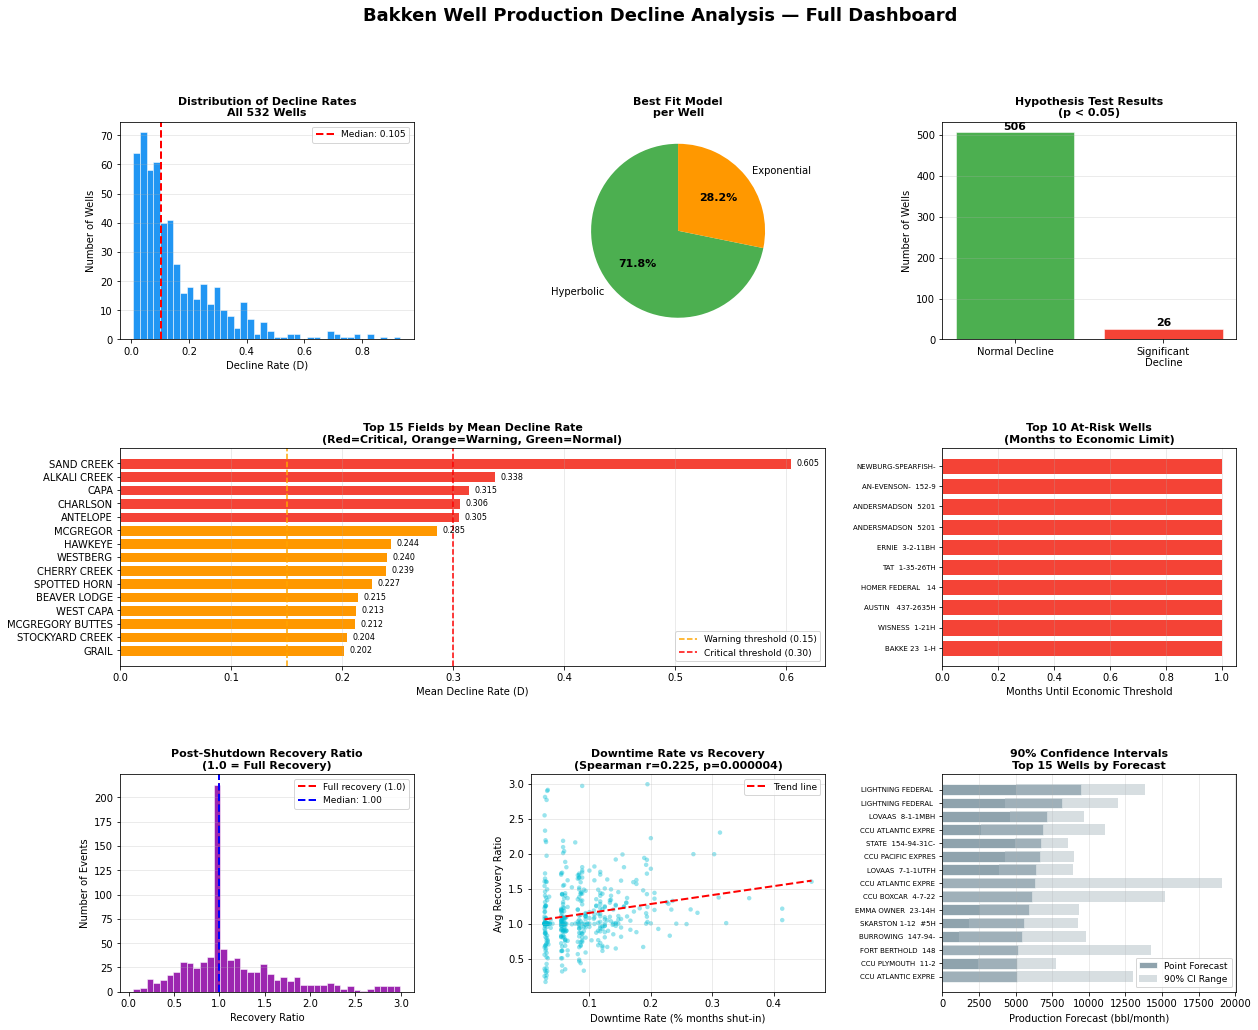

In [22]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Bakken Well Production Decline Analysis — Full Dashboard',
             fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

#  Chart 1: Decline Rate Distribution 
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_master['Best_D'], bins=40,
         color='#2196F3', edgecolor='white', linewidth=0.5)
ax1.axvline(df_master['Best_D'].median(), color='red',
            linewidth=2, linestyle='--',
            label=f"Median: {df_master['Best_D'].median():.3f}")
ax1.set_xlabel('Decline Rate (D)', fontsize=10)
ax1.set_ylabel('Number of Wells', fontsize=10)
ax1.set_title('Distribution of Decline Rates\nAll 532 Wells', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Chart 2: Best Model Pie Chart 
ax2 = fig.add_subplot(gs[0, 1])
model_counts = df_master['BestModel'].value_counts()
colors       = ['#4CAF50', '#FF9800']
wedges, texts, autotexts = ax2.pie(
    model_counts.values,
    labels=model_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax2.set_title('Best Fit Model\nper Well', fontsize=11, fontweight='bold')

# Chart 3: Hypothesis Test Results 
ax3 = fig.add_subplot(gs[0, 2])
sig_counts = df_master['Significant'].value_counts()
bars = ax3.bar(['Normal Decline', 'Significant\nDecline'],
               [sig_counts.get(False, 0), sig_counts.get(True, 0)],
               color=['#4CAF50', '#F44336'],
               edgecolor='white', linewidth=0.5)
ax3.set_ylabel('Number of Wells', fontsize=10)
ax3.set_title('Hypothesis Test Results\n(p < 0.05)', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{int(height)}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Chart 4: Top 15 Fields by Mean Decline Rate 
ax4 = fig.add_subplot(gs[1, :2])
top_fields = field_summary.head(15)
colors_field = ['#F44336' if d > 0.3 else '#FF9800'
                if d > 0.15 else '#4CAF50'
                for d in top_fields['Mean_D']]
bars = ax4.barh(top_fields['FieldName'], top_fields['Mean_D'],
                color=colors_field, edgecolor='white')
ax4.axvline(0.15, color='orange', linewidth=1.5,
            linestyle='--', label='Warning threshold (0.15)')
ax4.axvline(0.30, color='red', linewidth=1.5,
            linestyle='--', label='Critical threshold (0.30)')
ax4.set_xlabel('Mean Decline Rate (D)', fontsize=10)
ax4.set_title('Top 15 Fields by Mean Decline Rate\n(Red=Critical, Orange=Warning, Green=Normal)',
              fontsize=11, fontweight='bold')
ax4.invert_yaxis()
ax4.legend(fontsize=9)
ax4.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_fields['Mean_D']):
    ax4.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

# Chart 5: At Risk Wells — Months Until Threshold 
ax5 = fig.add_subplot(gs[1, 2])
at_risk_chart = (df_forecast[df_forecast['Crosses_Threshold']]
                 .sort_values('Months_Until_Threshold')
                 .head(10))
colors_risk = ['#F44336' if m <= 2 else '#FF9800'
               if m <= 4 else '#FFC107'
               for m in at_risk_chart['Months_Until_Threshold']]
ax5.barh(range(len(at_risk_chart)),
         at_risk_chart['Months_Until_Threshold'],
         color=colors_risk, edgecolor='white')
ax5.set_yticks(range(len(at_risk_chart)))
ax5.set_yticklabels([w[:18] for w in at_risk_chart['WellName']],
                     fontsize=7)
ax5.set_xlabel('Months Until Economic Threshold', fontsize=10)
ax5.set_title('Top 10 At-Risk Wells\n(Months to Economic Limit)',
              fontsize=11, fontweight='bold')
ax5.invert_yaxis()
ax5.grid(axis='x', alpha=0.3)

# Chart 6: Recovery Ratio Distribution 
ax6 = fig.add_subplot(gs[2, 0])
ax6.hist(df_recovery_clean['Recovery_Ratio'], bins=40,
         color='#9C27B0', edgecolor='white', linewidth=0.5)
ax6.axvline(1.0, color='red', linewidth=2,
            linestyle='--', label='Full recovery (1.0)')
ax6.axvline(df_recovery_clean['Recovery_Ratio'].median(),
            color='blue', linewidth=2, linestyle='--',
            label=f"Median: {df_recovery_clean['Recovery_Ratio'].median():.2f}")
ax6.set_xlabel('Recovery Ratio', fontsize=10)
ax6.set_ylabel('Number of Events', fontsize=10)
ax6.set_title('Post-Shutdown Recovery Ratio\n(1.0 = Full Recovery)',
              fontsize=11, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(axis='y', alpha=0.3)

# Chart 7: Correlation Scatter 
ax7 = fig.add_subplot(gs[2, 1])
scatter_df = corr_df3.copy()
ax7.scatter(scatter_df['Downtime_Rate'],
            scatter_df['Avg_Recovery'],
            alpha=0.4, color='#00BCD4',
            edgecolor='none', s=20)

# Add trend line
z = np.polyfit(scatter_df['Downtime_Rate'],
               scatter_df['Avg_Recovery'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['Downtime_Rate'].min(),
                     scatter_df['Downtime_Rate'].max(), 100)
ax7.plot(x_line, p(x_line), color='red',
         linewidth=2, linestyle='--', label='Trend line')
ax7.set_xlabel('Downtime Rate (% months shut-in)', fontsize=10)
ax7.set_ylabel('Avg Recovery Ratio', fontsize=10)
ax7.set_title(f'Downtime Rate vs Recovery\n(Spearman r=0.225, p=0.000004)',
              fontsize=11, fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(alpha=0.3)

# Chart 8: Confidence Interval Summary 
ax8 = fig.add_subplot(gs[2, 2])
ci_sample = df_ci.nlargest(15, 'Point_Forecast')
ax8.barh(range(len(ci_sample)), ci_sample['Point_Forecast'],
         color='#607D8B', edgecolor='white', alpha=0.7,
         label='Point Forecast')
ax8.barh(range(len(ci_sample)),
         ci_sample['CI_Upper_90'] - ci_sample['CI_Lower_90'],
         left=ci_sample['CI_Lower_90'],
         color='#B0BEC5', edgecolor='none', alpha=0.5,
         label='90% CI Range')
ax8.set_yticks(range(len(ci_sample)))
ax8.set_yticklabels([w[:18] for w in ci_sample['WellName']],
                     fontsize=7)
ax8.set_xlabel('Production Forecast (bbl/month)', fontsize=10)
ax8.set_title('90% Confidence Intervals\nTop 15 Wells by Forecast',
              fontsize=11, fontweight='bold')
ax8.invert_yaxis()
ax8.legend(fontsize=9)
ax8.grid(axis='x', alpha=0.3)

plt.savefig('bakken_decline_analysis_dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
print("✓ Final dashboard saved as 'bakken_decline_analysis_dashboard.png'")

In [23]:
# All my key results for Power BI (descriptive analysis)
df_master.to_csv('master_results.csv', index=False)
df_forecast.to_csv('forecast_results.csv', index=False)
df_ci.to_csv('confidence_intervals.csv', index=False)
df_recovery_clean.to_csv('recovery_analysis.csv', index=False)

In [24]:
# Make sure these all exist before merging
print(f"df_master rows:        {len(df_master)}")
print(f"df_forecast rows:      {len(df_forecast)}")
print(f"df_ci rows:            {len(df_ci)}")
print(f"df_recovery_clean rows:{len(df_recovery_clean)}")
print(f"field_summary rows:    {len(field_summary)}")

df_master rows:        532
df_forecast rows:      532
df_ci rows:            532
df_recovery_clean rows:801
field_summary rows:    45


In [25]:
from openpyxl import load_workbook

# Export all results to one Excel file 
output_path = 'bakken_decline_analysis.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    # Sheet 1: Master Results
    df_master.to_excel(writer, sheet_name='Master Results', index=False)

    # Sheet 2: Forecast Results
    df_forecast.to_excel(writer, sheet_name='Forecast Results', index=False)

    # Sheet 3: Confidence Intervals
    df_ci.to_excel(writer, sheet_name='Confidence Intervals', index=False)

    # Sheet 4: Recovery Analysis
    df_recovery_clean.to_excel(writer, sheet_name='Recovery Analysis', index=False)

    # Sheet 5: Field Summary
    field_summary.to_excel(writer, sheet_name='Field Summary', index=False)

print(f"✓ Excel file saved: {output_path}")
print(f"\nSheets created:")
print(f"  1. Master Results       — {len(df_master)} rows")
print(f"  2. Forecast Results     — {len(df_forecast)} rows")
print(f"  3. Confidence Intervals — {len(df_ci)} rows")
print(f"  4. Recovery Analysis    — {len(df_recovery_clean)} rows")
print(f"  5. Field Summary        — {len(field_summary)} rows")

✓ Excel file saved: bakken_decline_analysis.xlsx

Sheets created:
  1. Master Results       — 532 rows
  2. Forecast Results     — 532 rows
  3. Confidence Intervals — 532 rows
  4. Recovery Analysis    — 801 rows
  5. Field Summary        — 45 rows


In [26]:
import os
print(os.path.abspath('bakken_decline_analysis.xlsx'))

C:\Users\gbenga\Desktop\Well Production\bakken_decline_analysis.xlsx
